Universidad Torcuato Di Tella

Licenciatura en Tecnología Digital\
**Tecnología Digital VI: Inteligencia Artificial**

# **Visualización de filtros en redes CNN**

El objetivo de este *notebook* es mostrar como podemos observar qué pasa adentro de los filtros de las capas convolucionales, usando la misma red que la clase anterior (CNNs).

Usaremos el dataset [``EMNIST Letters``](https://www.nist.gov/itl/products-and-services/emnist-dataset).

Se trata de un *data set* de letras manuscritas, con 145.600 imágenes de 28x28 píxeles en escala de grises, distribuidas en 26 clases (una por cada letra del alfabeto inglés).

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import torch.utils.data
import numpy as np
from torch import nn
from torch import optim

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [ ]:
torch.manual_seed(100)
if torch.cuda.is_available():
    torch.cuda.manual_seed(100)

In [ ]:
train_transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(0, 1)])

val_transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize(0, 1)])

In [ ]:
batch_size = 32

train_set = torchvision.datasets.EMNIST(root = './data', split = 'letters', train = True, download = True, transform = train_transform)
test_set = torchvision.datasets.EMNIST(root = './data', split = 'letters', train = False, download = True, transform = val_transform)
targets_ = train_set.targets

train_idx, val_idx = train_test_split(np.arange(len(targets_)), test_size = 0.2, stratify = targets_)
train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
val_sampler = torch.utils.data.SubsetRandomSampler(val_idx)

trainloader = torch.utils.data.DataLoader(train_set, sampler = train_sampler, batch_size = batch_size, num_workers = 2)
valloader = torch.utils.data.DataLoader(train_set, sampler = val_sampler, batch_size = batch_size, num_workers = 2)

testloader = torch.utils.data.DataLoader(test_set, batch_size = batch_size, shuffle = False, num_workers = 2)

100%|██████████| 562M/562M [00:02<00:00, 192MB/s]


In [ ]:
print('Train set size:', len(train_set))
print('Test set size:', len(test_set))

Train set size: 124800
Test set size: 20800


Veamos cómo son las imágenes.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
def imshow(img, cmap = 'gray', vmin = None):
    img = img / 2 + 0.5 # Desnormalizamos.
    npimg = img.numpy()
    npimg = np.transpose(npimg, (1, 2, 0))
    npimg = np.rot90(npimg, 3)
    npimg = np.fliplr(npimg)
    plt.imshow(npimg, cmap = cmap, vmin = vmin)
    plt.show()

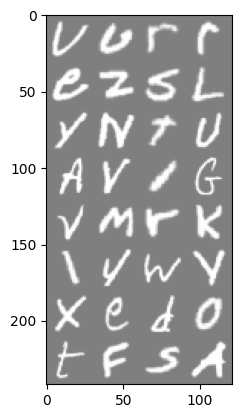

v     e     y     a     v     l     x     t     u     z     n     v     m     v     e     f     r     s     t     i     r     w     d     s     r     l     u     g     k     y     o     a    


In [ ]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{train_set.classes[labels[j]]:5s}' for j in range(batch_size)))

### **Probemos ahora con capas convolucionales**

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 1,   # 1 canal de entrada.
                               out_channels = 32, # 32 canales de salida.
                               kernel_size = 9,   # Kernel 3x3.
                               stride = 1,        # Pasos de 1.
                               padding = 4)       # Padding de 1 para mantener el tamaño.
        self.maxPool1 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.activation1 = nn.ReLU()
        self.conv2 = nn.Conv2d(32, 64,
                               kernel_size = 3, stride = 1, padding = 1)
        self.maxPool2 = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.fc1 = nn.Linear(64 * 7 * 7,
                             # 64 canales de 7x7 pues a la salida de cada capa
                             # convolucional se le aplica un maxpool de 2x2.
                             128)
        self.fc2 = nn.Linear(128, 26) # 26 clases para EMNIST letters.

    def forward(self, x):
        x = nn.ReLU()(self.conv1(x))
        x = self.maxPool1(x)
        x = self.activation1(self.conv2(x))
        x = self.maxPool2(x)
        x = torch.flatten(x, 1)
        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
net = CNN()
net.to(device)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (maxPool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (activation1): ReLU()
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (maxPool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=26, bias=True)
)

Definimos la función de pérdida y el optimizador.

In [ ]:
learning_rate = 0.01
momentum = 0.9

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr = learning_rate, momentum = momentum)

Entrenamos.

In [ ]:
epochs = 5

for epoch in range(epochs):

    running_loss = 0.0
    train_correct = 0
    total = 0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device) - 1

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_accuracy = 100 * train_correct / total
    running_loss = running_loss/total

    val_correct = 0
    total = 0
    val_loss = 0
    with torch.no_grad():
        for data in valloader:
            images, labels = data[0].to(device), data[1].to(device) - 1
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            val_loss += criterion(outputs, labels).item()

    val_accuracy = 100 * val_correct / total
    val_loss = val_loss / total

    print(f'Epoch {epoch + 1} finished. Train accuracy: {train_accuracy:.2f}%. Validation accuracy: {val_accuracy:.2f}%.')

print('Finished training.')

Epoch 1 finished. Train accuracy: 83.28%. Validation accuracy: 90.74%.
Epoch 2 finished. Train accuracy: 92.29%. Validation accuracy: 92.48%.
Epoch 3 finished. Train accuracy: 93.63%. Validation accuracy: 92.79%.
Epoch 4 finished. Train accuracy: 94.32%. Validation accuracy: 92.81%.
Epoch 5 finished. Train accuracy: 94.87%. Validation accuracy: 93.27%.
Finished training.


Ahora, veamos el accuracy en el conjunto de test.

Test accuracy: 93.23%.
Predicted:  a     a     a     a     a    
Ground truth:  a     a     a     a     a    


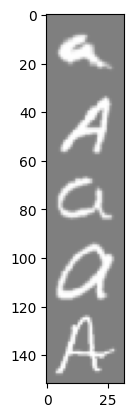

In [ ]:
correct = 0
total = 0

first_predicted = None
first_labels = None
first_images = None

with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device) - 1
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        if first_predicted is None:
            first_predicted = predicted
            first_labels = labels
            first_images = images
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f'Test accuracy: {accuracy:.2f}%.')

print('Predicted: ', ' '.join(f'{test_set.classes[first_predicted[j] + 1]:5s}' for j in range(5)))
print('Ground truth: ', ' '.join(f'{test_set.classes[first_labels[j] + 1]:5s}' for j in range(5)))

imshow(torchvision.utils.make_grid(first_images[:5].cpu()))

# Visualizando filtros convolucionales

In [ ]:
from torchvision import utils
# ch = canal que queremos ver
def visTensor(tensor, ch=0, allkernels=False, nrow=8, padding=1, normalize = False):
  n,c,w,h = tensor.shape

  if allkernels: tensor = tensor.view(n*c, -1, w, h) # -1 dice "no sé cuál es el valor de este parámetro, calculalo"
  elif c != 3: tensor = tensor[:,ch,:,:].unsqueeze(dim=1)

  tensor = tensor[:32] # no mostramos más de 32 filtros

  rows = np.min((tensor.shape[0] // nrow + 1, 16))
  grid = utils.make_grid(tensor, nrow=nrow, normalize = normalize, padding=padding)
  plt.figure( figsize=(nrow,rows) )
  plt.imshow(grid.numpy().transpose((1, 2, 0)))

Visualizamos los filtros de la primera capa (9x9) para el canal 0 (estamos en escala de grises)

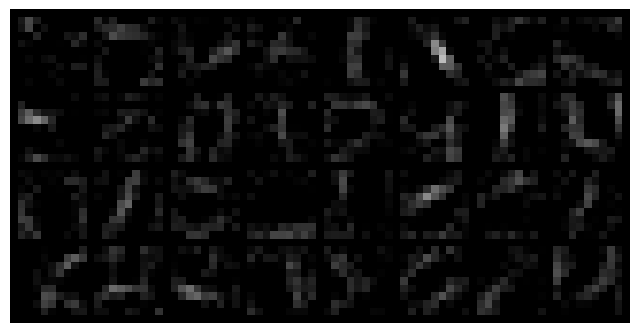

In [ ]:
filter = net.conv1.weight.data.clone()
visTensor(filter.cpu(), ch=0, allkernels=True, normalize = False)

plt.axis('off')
plt.ioff()
plt.show()

Visualizamos los filtros de la segunda capa (3x3)

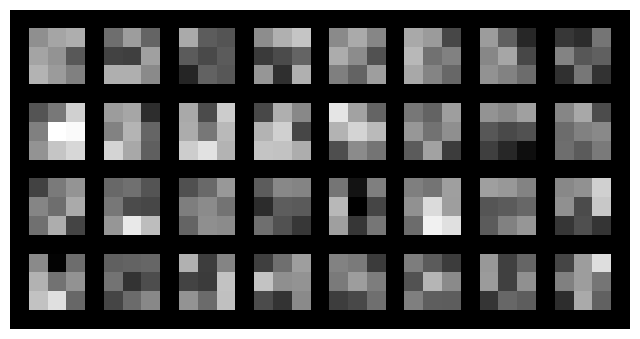

In [ ]:
filter = net.conv2.weight.data.clone()
visTensor(filter.cpu(), normalize = True, allkernels=False)

plt.axis('off')
plt.ioff()
plt.show()

No son demasiado claros. Pero, quizás podemos ver cómo se activan si pasamos una imagen. Por ejemplo, podemos elegir la siguiente imagen:

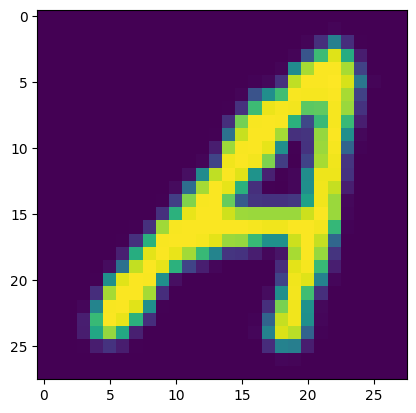

In [ ]:
imshow(first_images[1].cpu(), cmap = 'viridis')

In [ ]:
# Pass image through the first convolutional layer
# save the outpue
conv_layers = [net.conv1, net.maxPool1, net.activation1, net.conv2, net.maxPool2]
conv_out = [net.conv1(first_images[1])]
# Iteratively pass image through all convolutional layers
for i in range(1, len(conv_layers)):
  conv_out.append(conv_layers[i](conv_out[-1]))

In [ ]:
conv_out[0].shape

torch.Size([32, 28, 28])

In [ ]:
def imshow_grid(img, ax, cmap = 'gray', vmin = None):
    img = img / 2 + 0.5 # Desnormalizamos.
    npimg = img.numpy()
    npimg = np.transpose(npimg, (1, 2, 0))
    npimg = np.rot90(npimg, 3)
    npimg = np.fliplr(npimg)
    ax.imshow(npimg, cmap = cmap, vmin = vmin)

**Podemos** ver cómo se activa el primer filtro de las redes convolucionales. Es decir, visualizamos el primer mapa de activación resultante de la primera capa:

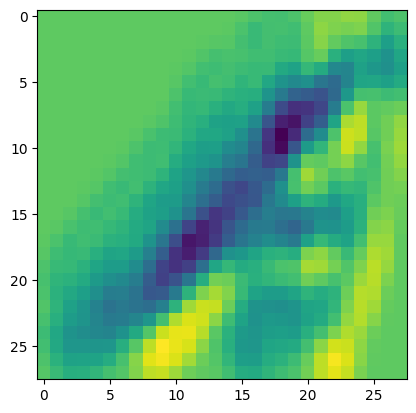

In [ ]:
imshow(conv_out[0][0].detach().cpu().unsqueeze(0), cmap='viridis')

O cómo se activa el segundo filtro de las capas convolucionales, es decir, el segundo mapa de activación resultante de la primera capa convolucional:

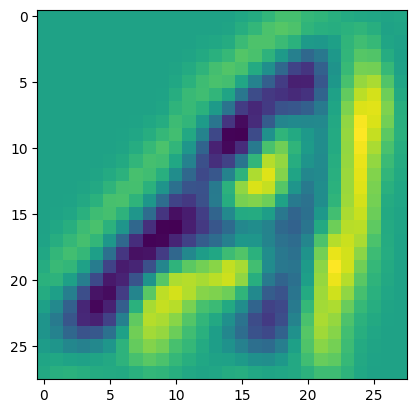

In [ ]:
imshow(conv_out[0][1].detach().cpu().unsqueeze(0), cmap='viridis')

Podemos ver cómo se activan los primeros 16 filtros de la primer capa convolucional:

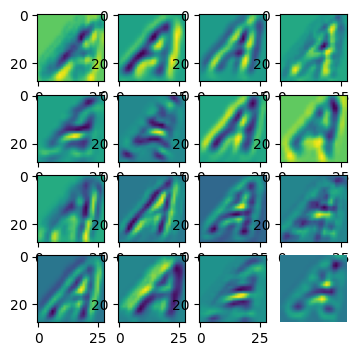

In [ ]:
fig, axs = plt.subplots(4, 4, figsize=(4, 4))
fig.gca().set_axis_off()
fig.gca().xaxis.set_major_locator(plt.NullLocator())
fig.gca().yaxis.set_major_locator(plt.NullLocator())
axs = axs.flatten()
for i in range(0, 16):
  imshow_grid(conv_out[0][i].detach().cpu().unsqueeze(0), axs[i], cmap='viridis')
plt.show()

Luego, podemos ver cómo queda la visualización después del primer *max pool*:

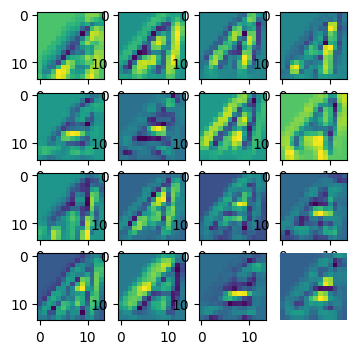

In [ ]:
fig, axs = plt.subplots(4, 4, figsize=(4, 4))
fig.gca().set_axis_off()
fig.gca().xaxis.set_major_locator(plt.NullLocator())
fig.gca().yaxis.set_major_locator(plt.NullLocator())
axs = axs.flatten()
for i in range(0, 16):
  imshow_grid(conv_out[1][i].detach().cpu().unsqueeze(0), axs[i], cmap='viridis')
plt.show()

Como esperamos, los mapas de activación resultantes quedan mas "escalonados", es decir, pierden resolución. Recordemos que una de las funciones de los mapas de activación es hacer que la detección de características sea relativamente indiferente a pequeños movimientos de la imagen.

¿Qué pasa después de aplicar ReLU?

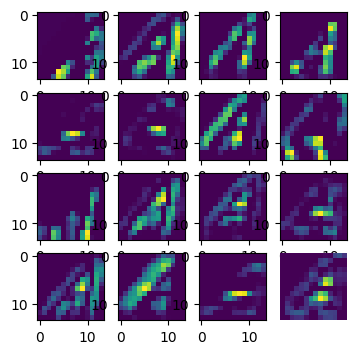

In [ ]:
fig, axs = plt.subplots(4, 4, figsize=(4, 4))
fig.gca().set_axis_off()
fig.gca().xaxis.set_major_locator(plt.NullLocator())
fig.gca().yaxis.set_major_locator(plt.NullLocator())
axs = axs.flatten()
for i in range(0, 16):
  imshow_grid(conv_out[2][i].detach().cpu().unsqueeze(0), axs[i], cmap='viridis')
plt.show()

Quedan solo los valores positivos de los mapas de características.

Y, ¿después de la segunda capa convolucional?

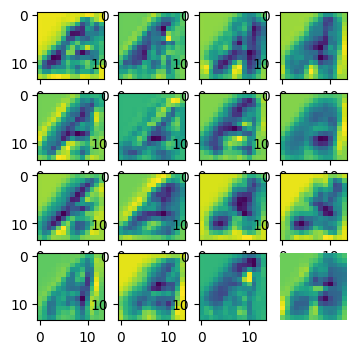

In [ ]:
fig, axs = plt.subplots(4, 4, figsize=(4, 4))
fig.gca().set_axis_off()
fig.gca().xaxis.set_major_locator(plt.NullLocator())
fig.gca().yaxis.set_major_locator(plt.NullLocator())
axs = axs.flatten()
for i in range(0, 16):
  imshow_grid(conv_out[3][i].detach().cpu().unsqueeze(0), axs[i], cmap='viridis')
plt.show()

Los patrones se van volviendo mas abstractos y menos reconocibles.

Y, ¿después del segundo max pool?

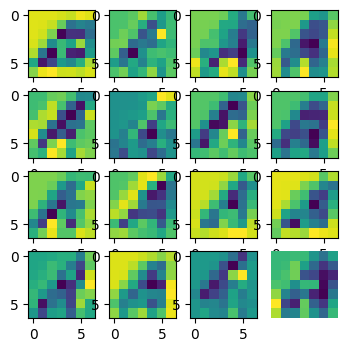

In [ ]:
fig, axs = plt.subplots(4, 4, figsize=(4, 4))
fig.gca().set_axis_off()
fig.gca().xaxis.set_major_locator(plt.NullLocator())
fig.gca().yaxis.set_major_locator(plt.NullLocator())
axs = axs.flatten()
for i in range(0, 16):
  imshow_grid(conv_out[4][i].detach().cpu().unsqueeze(0), axs[i], cmap='viridis')
plt.show()

Vemos que las primeras capas convolucionales parecen detectar bordes y detalles, mientras que las más profundas detectan características más abstractas y generales, y su interpretación se vuelve más difícil.